# The results in this notebook are included in 260206

In [65]:
import pandas as pd, re
from pathlib import Path

### pbe1pbe/def2svp gd3bj sp energies

In [67]:
def parse_ml(path):
    text = Path(path).read_text()
    rows=[]
    for line in text.splitlines():
        m = re.search(r'^(5[ab]_[^:]+):\s+SCF Done:.*=\s*([-\d\.]+)', line)
        print(m)
        if m:
            raw = m.group(1) # (5[ab]_[^:]+)
            energy = float(m.group(2)) # ([-\d\.]+)
            group = re.match(r'^(5[ab])_', raw).group(1)
            name = re.sub(r'^5[ab]_pbe0_', '', raw).replace('.log','')
            rows.append((name, group, energy))
    return pd.DataFrame(rows, columns=["opt method","group","energy_au"])

def parse_original(path):
    text = Path(path).read_text()
    rows=[]
    for line in text.splitlines():
        m = re.search(r'^(5[ab])_(pbe0|pbe)\s+SCF Done:.*=\s*([-\d\.]+)', line)
        if m:
            group = m.group(1)
            name = m.group(2)      # keep as "pbe0" and "pbe"
            energy = float(m.group(3))
            rows.append((name, group, energy))
    return pd.DataFrame(rows, columns=["opt method","group","energy_au"])

In [68]:
df = pd.concat([
    parse_ml("/home/zining/TiO2/tio2_ChenDixon_gjf/pbe0_energy_5ml_summary.txt"),
    parse_original("/home/zining/TiO2/tio2_ChenDixon_gjf/pbe0_energy_5original_summary.txt"),
], ignore_index=True)

final_df = (
    df.pivot_table(index="opt method", columns="group", values="energy_au", aggfunc="first")
      .reset_index()
)
final_df["dE_au"] = final_df["5b"] - final_df["5a"]
final_df = final_df[["opt method","5a","5b","dE_au"]].sort_values("opt method").reset_index(drop=True)



<re.Match object; span=(0, 64), match='5a_pbe0_matpes_pbe.log: SCF Done:  E(RPBE1PBE) = >
<re.Match object; span=(0, 67), match='5a_pbe0_matpes_r2scan.log: SCF Done:  E(RPBE1PBE)>
<re.Match object; span=(0, 57), match='5a_pbe0_mpa.log: SCF Done:  E(RPBE1PBE) =  -4997.>
<re.Match object; span=(0, 64), match='5a_pbe0_omol25_low.log: SCF Done:  E(RPBE1PBE) = >
<re.Match object; span=(0, 64), match='5b_pbe0_matpes_pbe.log: SCF Done:  E(RPBE1PBE) = >
<re.Match object; span=(0, 67), match='5b_pbe0_matpes_r2scan.log: SCF Done:  E(RPBE1PBE)>
<re.Match object; span=(0, 57), match='5b_pbe0_mpa.log: SCF Done:  E(RPBE1PBE) =  -4997.>
<re.Match object; span=(0, 64), match='5b_pbe0_omol25_low.log: SCF Done:  E(RPBE1PBE) = >


In [69]:
final_df

group,opt method,5a,5b,dE_au
0,matpes_pbe,-4997.600685,-4997.610234,-0.009549
1,matpes_r2scan,-4997.607814,-4997.618139,-0.010325
2,mpa,-4997.601188,-4997.610555,-0.009367
3,omol25_low,-4997.614614,-4997.625085,-0.010471
4,pbe,-4997.612599,-4997.623550,-0.010951
5,pbe0,-4997.617272,-4997.628051,-0.010779


In [70]:
hartree_to_eV = 27.2114
col_ev = final_df["dE_au"] * hartree_to_eV
col_ev = col_ev.to_frame()
col_ev.columns = ["dE_eV"]

final_df_1 = pd.concat([final_df, col_ev], axis=1)

print(final_df_1)

gs_energy = final_df_1["5a"][5]
final_df_1.loc[:, ["5a", "5b"]] -= gs_energy
final_df_1


      opt method           5a           5b     dE_au     dE_eV
0     matpes_pbe -4997.600685 -4997.610234 -0.009549 -0.259836
1  matpes_r2scan -4997.607814 -4997.618139 -0.010325 -0.280950
2            mpa -4997.601188 -4997.610555 -0.009367 -0.254893
3     omol25_low -4997.614614 -4997.625085 -0.010471 -0.284932
4            pbe -4997.612599 -4997.623550 -0.010951 -0.297980
5           pbe0 -4997.617272 -4997.628051 -0.010779 -0.293325


,opt method,5a,5b,dE_au,dE_eV
0,matpes_pbe,0.016587,0.007038,-0.009549,-0.259836
1,matpes_r2scan,0.009457,-0.000867,-0.010325,-0.280950
2,mpa,0.016084,0.006717,-0.009367,-0.254893
3,omol25_low,0.002658,-0.007813,-0.010471,-0.284932
4,pbe,0.004672,-0.006278,-0.010951,-0.297980
5,pbe0,0.000000,-0.010779,-0.010779,-0.293325


In [71]:
a_ev = final_df_1["5a"] * hartree_to_eV
b_ev = final_df_1["5b"] * hartree_to_eV
final_df_1.insert(4, "5a_eV", a_ev)
final_df_1.insert(5, "5b_eV", b_ev)
final_df_1

,opt method,5a,5b,dE_au,5a_eV,5b_eV,dE_eV
0,matpes_pbe,0.016587,0.007038,-0.009549,0.451352,0.191516,-0.259836
1,matpes_r2scan,0.009457,-0.000867,-0.010325,0.257352,-0.023598,-0.280950
2,mpa,0.016084,0.006717,-0.009367,0.437665,0.182772,-0.254893
3,omol25_low,0.002658,-0.007813,-0.010471,0.072324,-0.212608,-0.284932
4,pbe,0.004672,-0.006278,-0.010951,0.127142,-0.170838,-0.297980
5,pbe0,0.000000,-0.010779,-0.010779,0.000000,-0.293325,-0.293325


# RMSD

In [72]:
df_rmsd = pd.read_csv("opt_structures/rmsd.csv")


In [73]:
df_rmsd

,opt methods,5a RMSD (Å),5b RMSD (Å),5a_pbe RMSD (Å),5b_pbe RMSD (Å)
0,matpes_pbe,0.078934,0.084292,NaN,NaN
1,omol25_low,0.065926,0.045787,NaN,NaN
2,mpa,0.071083,0.082400,NaN,NaN
3,matpes_r2scan,0.074738,0.047113,NaN,NaN
4,opt_structures,NaN,NaN,0.024675,0.025131


In [74]:
df_rmsd.iloc[4, [1,2]] = df_rmsd.iloc[4, [3,4]]
df_rmsd1 = df_rmsd.drop(columns=df_rmsd.columns[[3,4]])
df_rmsd1


,opt methods,5a RMSD (Å),5b RMSD (Å)
0,matpes_pbe,0.078934,0.084292
1,omol25_low,0.065926,0.045787
2,mpa,0.071083,0.082400
3,matpes_r2scan,0.074738,0.047113
4,opt_structures,0.024675,0.025131


In [75]:
df_rmsd1.loc[4, 'opt methods'] = 'pbe'
df_rmsd1

,opt methods,5a RMSD (Å),5b RMSD (Å)
0,matpes_pbe,0.078934,0.084292
1,omol25_low,0.065926,0.045787
2,mpa,0.071083,0.082400
3,matpes_r2scan,0.074738,0.047113
4,pbe,0.024675,0.025131


In [76]:
new_row_index = df_rmsd1.columns
print(new_row_index)

df_rmsdi = df_rmsd1.set_index("opt methods")
df_rmsdi.at['pbe0', "5a RMSD (Å)"] = 0.
df_rmsdi.at['pbe0', "5b RMSD (Å)"] = 0.

df_rmsdi

Index(['opt methods', '5a RMSD (Å)', '5b RMSD (Å)'], dtype='object')


,5a RMSD (Å),5b RMSD (Å)
opt methods,,
matpes_pbe,0.078934,0.084292
omol25_low,0.065926,0.045787
mpa,0.071083,0.082400
matpes_r2scan,0.074738,0.047113
pbe,0.024675,0.025131
pbe0,0.000000,0.000000


# Combine

In [77]:
print(final_df_1.columns[[0,1,2]])
df_energy = final_df_1.rename(columns={'opt method': 'opt methods'})

df_energyi = df_energy.set_index("opt methods")

df_energyi = df_energyi.drop(columns=df_energyi.columns[[0,1,2]])
df_energyi


Index(['opt method', '5a', '5b'], dtype='object')


,5a_eV,5b_eV,dE_eV
opt methods,,,
matpes_pbe,0.451352,0.191516,-0.259836
matpes_r2scan,0.257352,-0.023598,-0.280950
mpa,0.437665,0.182772,-0.254893
omol25_low,0.072324,-0.212608,-0.284932
pbe,0.127142,-0.170838,-0.297980
pbe0,0.000000,-0.293325,-0.293325


In [78]:
df_out = df_rmsdi.join(df_energyi)
df_out

,5a RMSD (Å),5b RMSD (Å),5a_eV,5b_eV,dE_eV
opt methods,,,,,
matpes_pbe,0.078934,0.084292,0.451352,0.191516,-0.259836
omol25_low,0.065926,0.045787,0.072324,-0.212608,-0.284932
mpa,0.071083,0.082400,0.437665,0.182772,-0.254893
matpes_r2scan,0.074738,0.047113,0.257352,-0.023598,-0.280950
pbe,0.024675,0.025131,0.127142,-0.170838,-0.297980
pbe0,0.000000,0.000000,0.000000,-0.293325,-0.293325


In [79]:
import matplotlib.pyplot as plt
from matplotlib import cm

print(df_out.columns)

Index(['5a RMSD (Å)', '5b RMSD (Å)', '5a_eV', '5b_eV', 'dE_eV'], dtype='object')


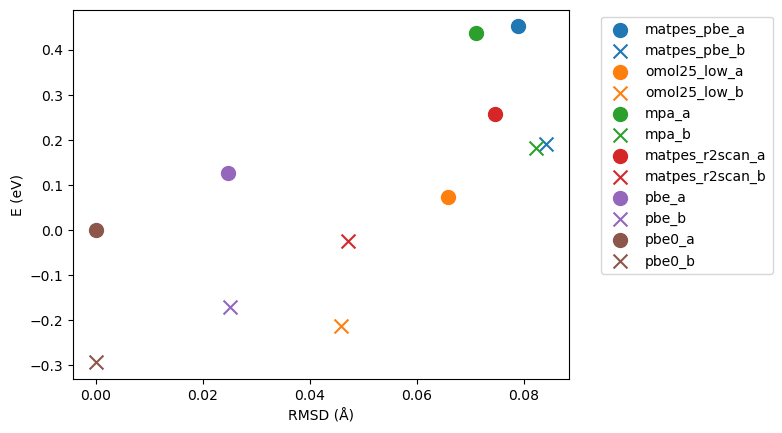

In [80]:
fig, ax = plt.subplots()
colors = cm.tab10.colors

for i, method in enumerate(df_out.index):
    color = colors[i]
    row = df_out.loc[method]
    ax.scatter(row['5a RMSD (Å)'], row['5a_eV'], label=method+'_a', s=100, color=color)
    ax.scatter(row['5b RMSD (Å)'], row['5b_eV'], label=method+'_b', s=100, marker='x', color=color)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('RMSD (Å)')
ax.set_ylabel('E (eV)')
plt.show()

def2tzvp